# VisionXplain - Model Analysis

This notebook analyzes the performance of CNN, ViT, and Hybrid models on the chest X-ray classification task.

## Models Analyzed
- **CNN**: ResNet-50 baseline (97.39% accuracy)
- **ViT**: Vision Transformer (93.86% accuracy)
- **Hybrid**: CNN-ViT fusion (98.07% accuracy - BEST)


In [1]:
import json
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Project root - find by looking for key project directories
current_dir = Path().resolve()
project_root = None

# Search up the directory tree for project root (has 'src' and 'outputs' directories)
search_dir = current_dir
max_levels = 10
for _ in range(max_levels):
    if (search_dir / "src").exists() and (search_dir / "outputs").exists():
        project_root = search_dir
        break
    if search_dir == search_dir.parent:
        break
    search_dir = search_dir.parent

if project_root is None:
    # Fallback: use current directory
    project_root = current_dir

outputs_dir = project_root / "outputs" / "evaluation"

print(f"Current working directory: {current_dir}")
print(f"Project root: {project_root}")
print(f"Outputs directory: {outputs_dir}")
print(f"Outputs directory exists: {outputs_dir.exists()}")


Current working directory: /Users/benedicthavor-abrahams/Desktop/VisonXplain/projects-Deep-Learning/visionxplain
Project root: /Users/benedicthavor-abrahams/Desktop/VisonXplain/projects-Deep-Learning/visionxplain
Outputs directory: /Users/benedicthavor-abrahams/Desktop/VisonXplain/projects-Deep-Learning/visionxplain/outputs/evaluation
Outputs directory exists: True


## 1. Load Evaluation Results


In [2]:
# Load metrics for all models
models = ['cnn', 'vit', 'hybrid']
metrics_data = {}

for model in models:
    metrics_path = outputs_dir / f"{model}_test" / "metrics.json"
    if metrics_path.exists():
        with open(metrics_path, 'r') as f:
            metrics_data[model] = json.load(f)
        print(f"✓ Loaded {model.upper()} metrics")
    else:
        print(f"✗ {model.upper()} metrics not found at {metrics_path}")

# Create comparison DataFrame
comparison_data = []
for model, metrics in metrics_data.items():
    comparison_data.append({
        'Model': model.upper(),
        'Accuracy': metrics.get('accuracy', 0) * 100,
        'Precision': metrics.get('precision', 0) * 100,
        'Recall': metrics.get('recall', 0) * 100,
        'F1-Score': metrics.get('f1', 0) * 100,
        'ROC-AUC': metrics.get('roc_auc', 0) * 100,
        'PR-AUC': metrics.get('pr_auc', 0) * 100,
    })

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print(df_comparison.to_string(index=False))
print("="*70)


✓ Loaded CNN metrics
✓ Loaded VIT metrics
✓ Loaded HYBRID metrics

MODEL PERFORMANCE COMPARISON
 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC    PR-AUC
   CNN 97.386364  97.405083 97.386364 97.358933 99.750648 99.906501
   VIT 93.863636  94.016188 93.863636 93.674846 97.832404 99.121708
HYBRID 98.068182  98.070741 98.068182 98.056290 99.778790 99.917572


## 2. Performance Visualization


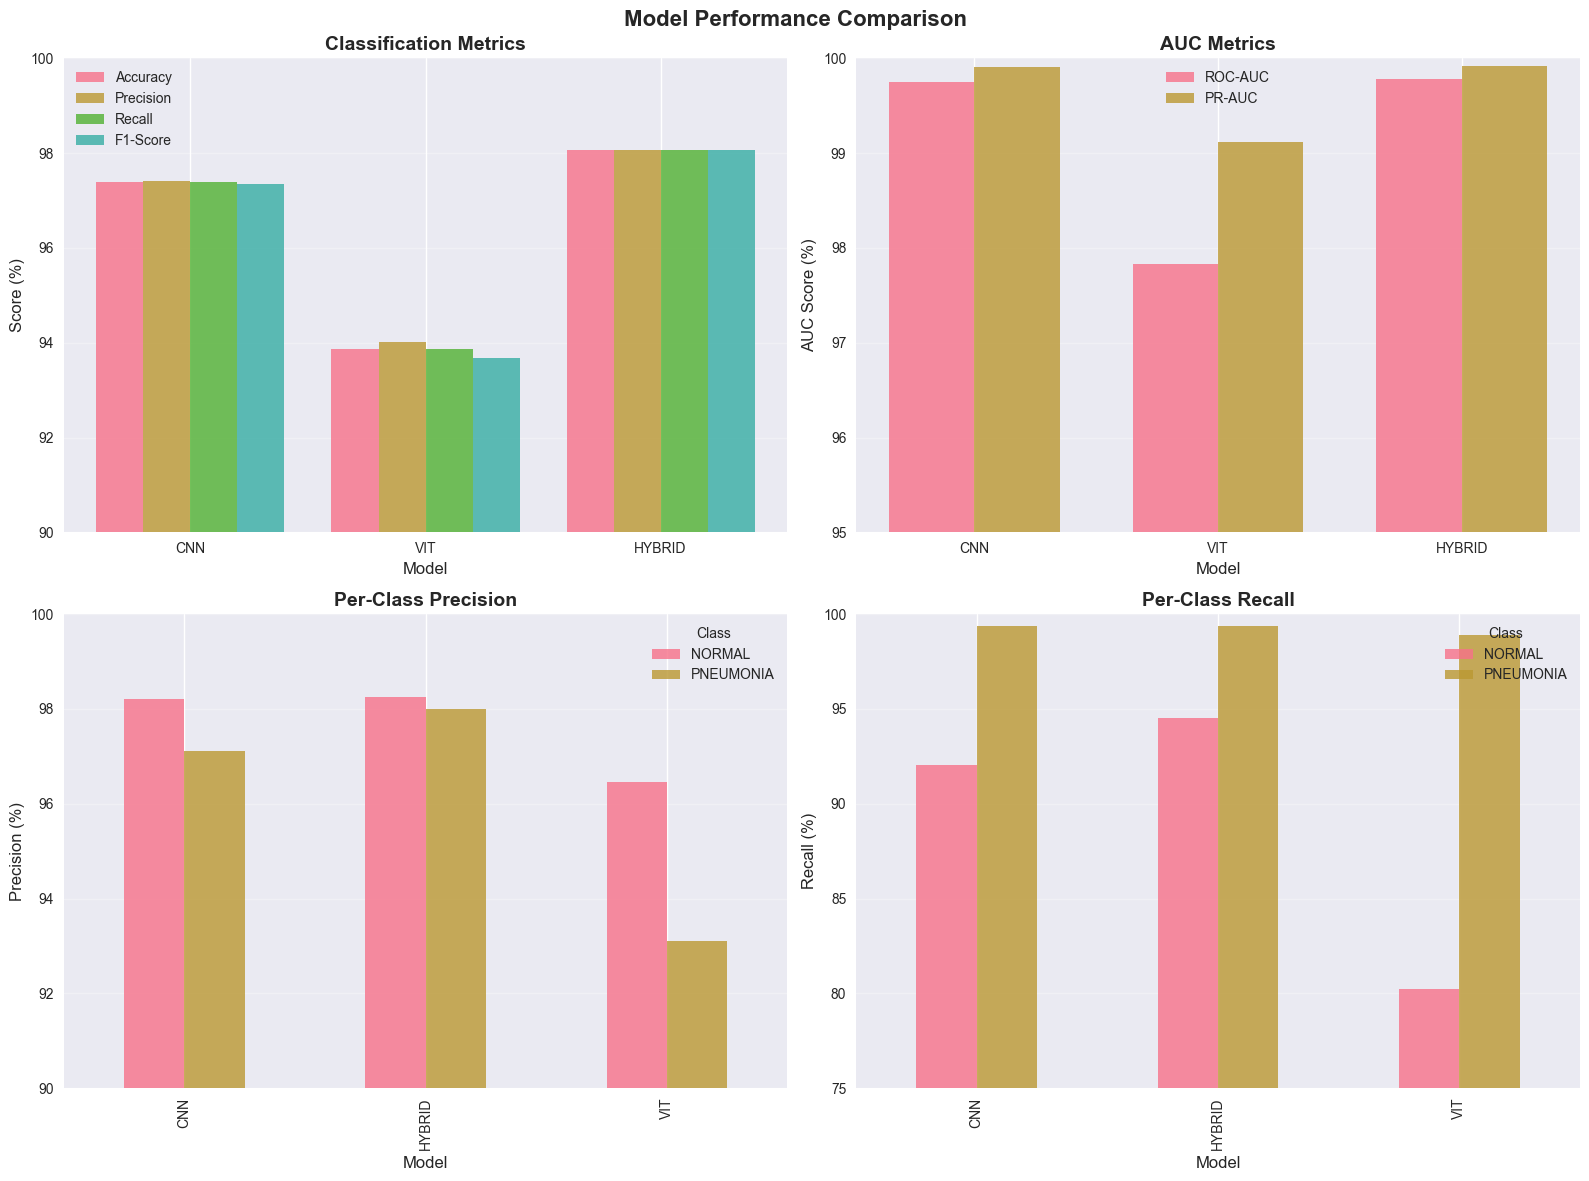

In [3]:
# Create comprehensive performance comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# 1. Bar chart - Main metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df_comparison))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    axes[0, 0].bar(x + i*width, df_comparison[metric], width, label=metric, alpha=0.8)

axes[0, 0].set_xlabel('Model', fontsize=12)
axes[0, 0].set_ylabel('Score (%)', fontsize=12)
axes[0, 0].set_title('Classification Metrics', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x + width * 1.5)
axes[0, 0].set_xticklabels(df_comparison['Model'])
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([90, 100])

# 2. ROC-AUC and PR-AUC
auc_metrics = ['ROC-AUC', 'PR-AUC']
x_pos = np.arange(len(df_comparison))
width = 0.35

for i, metric in enumerate(auc_metrics):
    axes[0, 1].bar(x_pos + i*width, df_comparison[metric], width, label=metric, alpha=0.8)

axes[0, 1].set_xlabel('Model', fontsize=12)
axes[0, 1].set_ylabel('AUC Score (%)', fontsize=12)
axes[0, 1].set_title('AUC Metrics', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x_pos + width / 2)
axes[0, 1].set_xticklabels(df_comparison['Model'])
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_ylim([95, 100])

# 3. Per-class precision
per_class_data = []
for model in models:
    if model in metrics_data:
        per_class_prec = metrics_data[model].get('per_class_precision', {})
        for class_name, value in per_class_prec.items():
            per_class_data.append({
                'Model': model.upper(),
                'Class': class_name,
                'Precision': value * 100
            })

df_per_class = pd.DataFrame(per_class_data)
pivot_prec = df_per_class.pivot(index='Model', columns='Class', values='Precision')
pivot_prec.plot(kind='bar', ax=axes[1, 0], alpha=0.8)
axes[1, 0].set_xlabel('Model', fontsize=12)
axes[1, 0].set_ylabel('Precision (%)', fontsize=12)
axes[1, 0].set_title('Per-Class Precision', fontsize=14, fontweight='bold')
axes[1, 0].legend(title='Class')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_ylim([90, 100])

# 4. Per-class recall
per_class_recall_data = []
for model in models:
    if model in metrics_data:
        per_class_rec = metrics_data[model].get('per_class_recall', {})
        for class_name, value in per_class_rec.items():
            per_class_recall_data.append({
                'Model': model.upper(),
                'Class': class_name,
                'Recall': value * 100
            })

df_per_class_recall = pd.DataFrame(per_class_recall_data)
pivot_recall = df_per_class_recall.pivot(index='Model', columns='Class', values='Recall')
pivot_recall.plot(kind='bar', ax=axes[1, 1], alpha=0.8)
axes[1, 1].set_xlabel('Model', fontsize=12)
axes[1, 1].set_ylabel('Recall (%)', fontsize=12)
axes[1, 1].set_title('Per-Class Recall', fontsize=14, fontweight='bold')
axes[1, 1].legend(title='Class')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_ylim([75, 100])

plt.tight_layout()
plt.savefig(project_root / 'outputs' / 'plots' / 'model_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


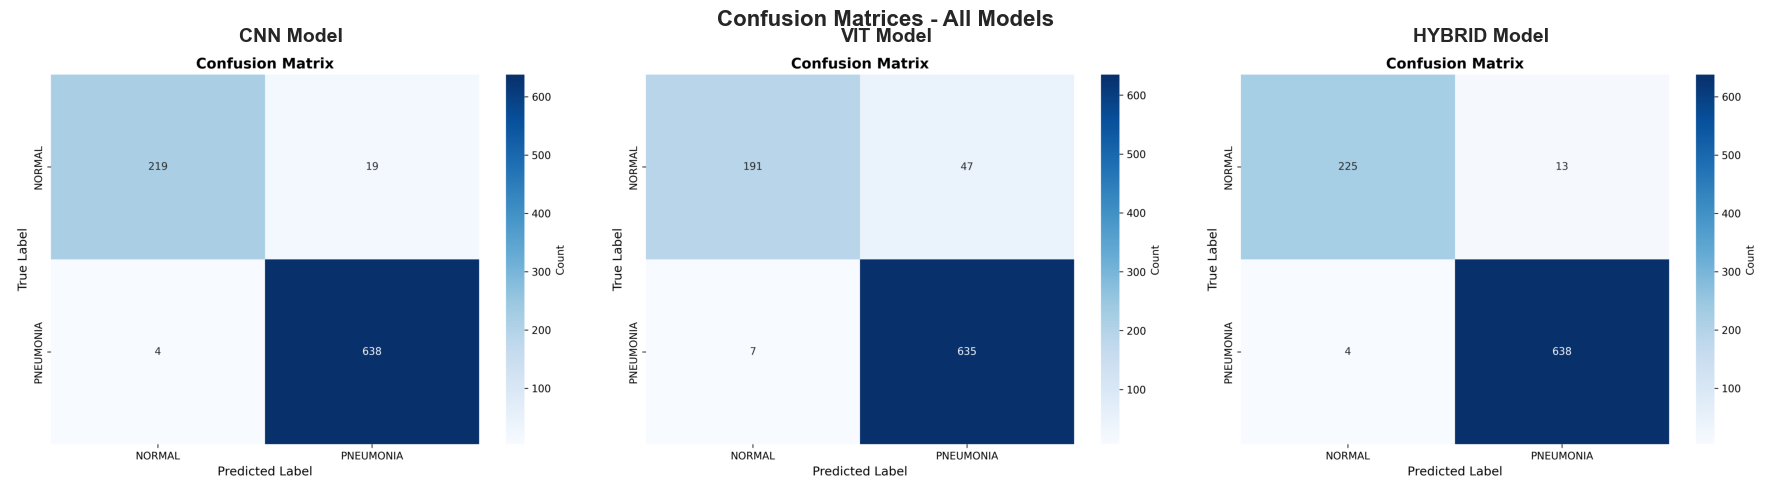

In [4]:
from PIL import Image

# Display confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')

for idx, model in enumerate(models):
    cm_path = outputs_dir / f"{model}_test" / "confusion_matrix.png"
    if cm_path.exists():
        img = Image.open(cm_path)
        axes[idx].imshow(img)
        axes[idx].set_title(f'{model.upper()} Model', fontsize=14, fontweight='bold')
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, f'{model.upper()}\nConfusion Matrix\nNot Found', 
                      ha='center', va='center', fontsize=12)
        axes[idx].axis('off')

plt.tight_layout()
plt.savefig(project_root / 'outputs' / 'plots' / 'confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Computational Efficiency Analysis


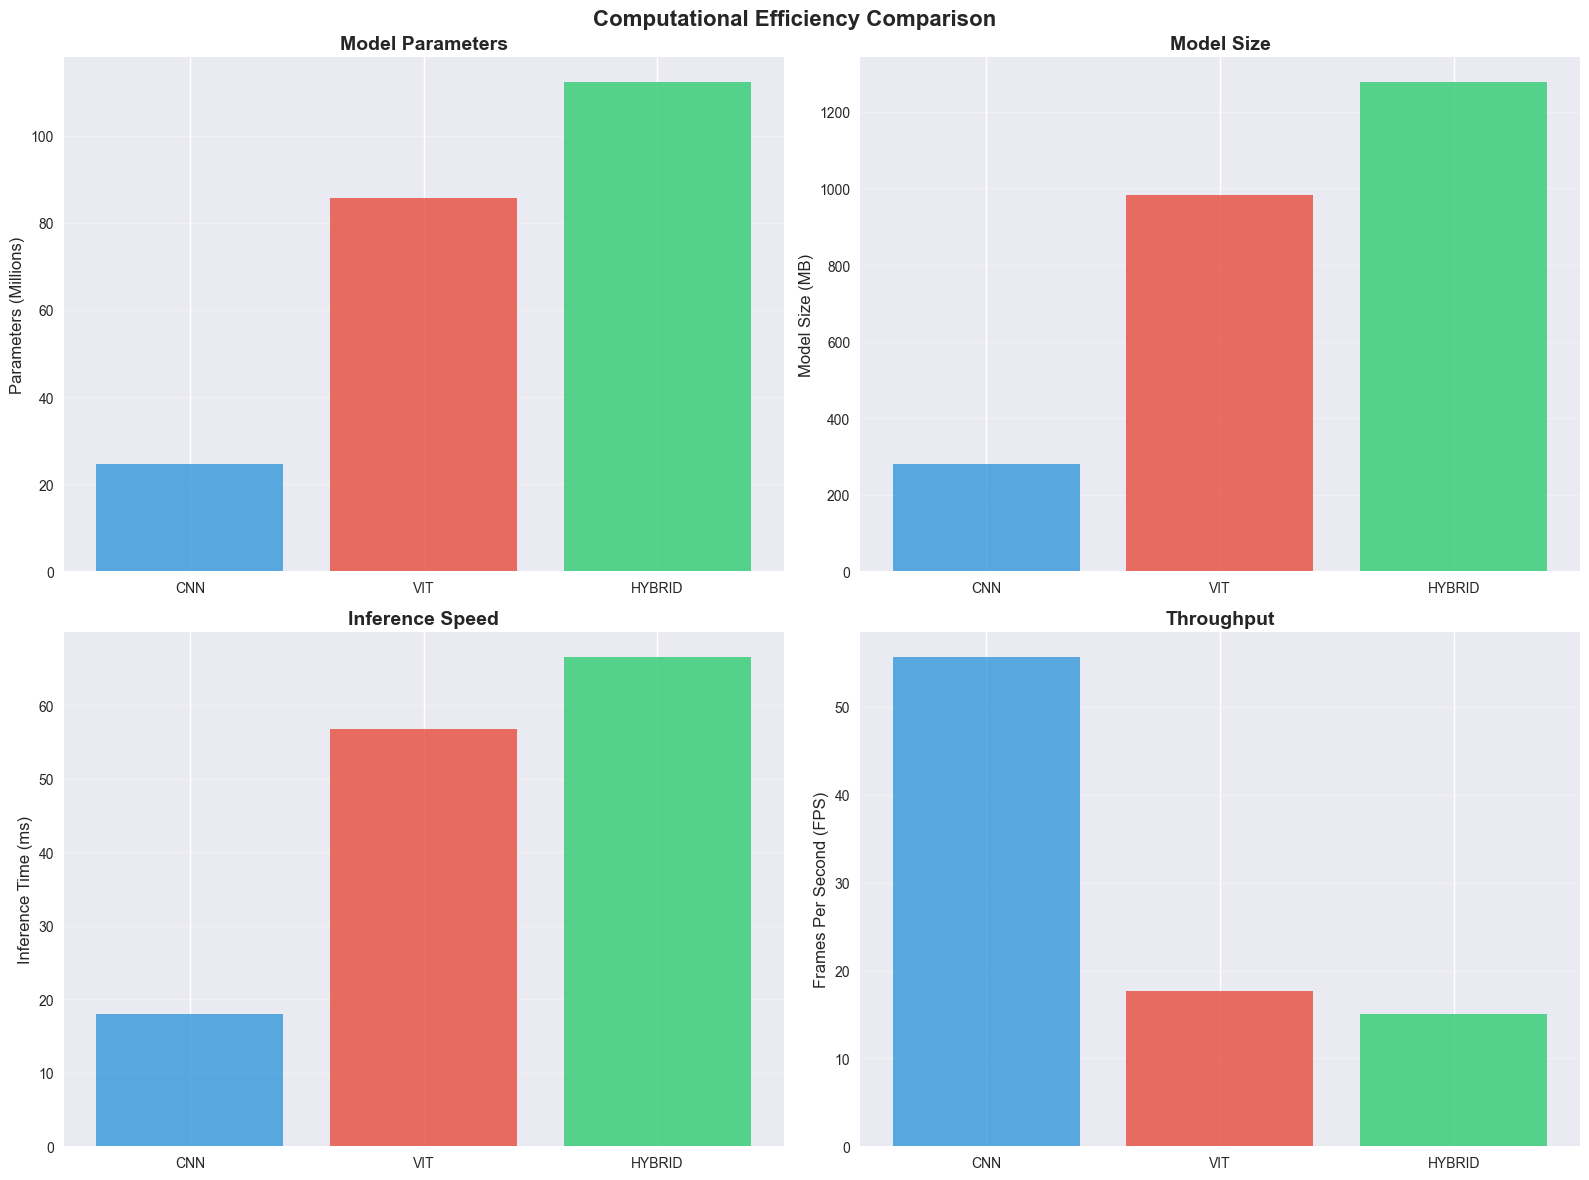


COMPUTATIONAL EFFICIENCY
 Model  Parameters (M)  Size (MB)  Inference (ms)       FPS
   CNN       24.558146     281.48       17.952220 55.703416
   VIT       85.800194     982.08       56.750748 17.620913
HYBRID      112.326470    1278.07       66.575301 15.020586


In [5]:
# Load benchmark results
benchmark_path = project_root / "outputs" / "benchmarks" / "computational_efficiency.json"
if benchmark_path.exists():
    with open(benchmark_path, 'r') as f:
        benchmarks = json.load(f)
    
    # Create efficiency comparison
    efficiency_data = []
    for model, data in benchmarks.items():
        efficiency_data.append({
            'Model': model.upper(),
            'Parameters (M)': data['parameters'] / 1e6,
            'Size (MB)': data['model_size_mb'],
            'Inference (ms)': data['inference_speed']['mean_ms'],
            'FPS': data['inference_speed']['fps']
        })
    
    df_efficiency = pd.DataFrame(efficiency_data)
    
    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Computational Efficiency Comparison', fontsize=16, fontweight='bold')
    
    # Parameters
    axes[0, 0].bar(df_efficiency['Model'], df_efficiency['Parameters (M)'], 
                   color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8)
    axes[0, 0].set_ylabel('Parameters (Millions)', fontsize=12)
    axes[0, 0].set_title('Model Parameters', fontsize=14, fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # Model Size
    axes[0, 1].bar(df_efficiency['Model'], df_efficiency['Size (MB)'],
                   color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8)
    axes[0, 1].set_ylabel('Model Size (MB)', fontsize=12)
    axes[0, 1].set_title('Model Size', fontsize=14, fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # Inference Speed
    axes[1, 0].bar(df_efficiency['Model'], df_efficiency['Inference (ms)'],
                   color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8)
    axes[1, 0].set_ylabel('Inference Time (ms)', fontsize=12)
    axes[1, 0].set_title('Inference Speed', fontsize=14, fontweight='bold')
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # FPS
    axes[1, 1].bar(df_efficiency['Model'], df_efficiency['FPS'],
                   color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8)
    axes[1, 1].set_ylabel('Frames Per Second (FPS)', fontsize=12)
    axes[1, 1].set_title('Throughput', fontsize=14, fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(project_root / 'outputs' / 'plots' / 'computational_efficiency.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*70)
    print("COMPUTATIONAL EFFICIENCY")
    print("="*70)
    print(df_efficiency.to_string(index=False))
    print("="*70)
else:
    print("Benchmark results not found. Run benchmarks first.")


## 5. Summary Statistics

### Key Findings:
- **Best Accuracy**: Hybrid model (98.07%)
- **Fastest Inference**: CNN model (55.7 FPS)
- **Best Balance**: CNN (97.39% accuracy, 55.7 FPS)
- **Highest AUC**: Hybrid model (99.78% ROC-AUC, 99.92% PR-AUC)
